In [1]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.model_selection import cross_val_score
import optuna

In [2]:
df = pd.read_csv('gemini.csv')

In [3]:
y = df['З/П']
X = df.drop(['З/П'], axis = 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

In [4]:
from sklearn.neighbors import KNeighborsClassifier
def objective(trial):
    # Подбираем количество соседей
    n_neighbors = trial.suggest_int("n_neighbors", 1, 30)
    
    # Подбираем веса: одинаковые или зависящие от расстояния
    weights = trial.suggest_categorical("weights", ["uniform", "distance"])
    
    # Подбираем метрику расстояния
    metric = trial.suggest_categorical("metric", ["euclidean", "manhattan", "minkowski"])
    
    # Если метрика minkowski, можно подобрать степень p
    if metric == "minkowski":
        p = trial.suggest_int("p", 1, 5)
    else:
        p = 2 # По умолчанию для других метрик

    model = KNeighborsClassifier(
        n_neighbors=n_neighbors,
        weights=weights,
        metric=metric,
        p=p
    )

    score = cross_val_score(model, X_train, y_train, cv=5).mean()
    return score
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=40) 
best_params = study.best_params

[I 2026-04-23 17:37:47,110] A new study created in memory with name: no-name-35f3ce13-1845-4071-9c3e-a199e9e19fda
[I 2026-04-23 17:37:49,003] Trial 0 finished with value: 0.6892857142857143 and parameters: {'n_neighbors': 4, 'weights': 'uniform', 'metric': 'euclidean'}. Best is trial 0 with value: 0.6892857142857143.
[I 2026-04-23 17:37:49,041] Trial 1 finished with value: 0.7464285714285714 and parameters: {'n_neighbors': 6, 'weights': 'distance', 'metric': 'euclidean'}. Best is trial 1 with value: 0.7464285714285714.
[I 2026-04-23 17:37:49,069] Trial 2 finished with value: 0.775 and parameters: {'n_neighbors': 5, 'weights': 'uniform', 'metric': 'manhattan'}. Best is trial 2 with value: 0.775.
[I 2026-04-23 17:37:49,113] Trial 3 finished with value: 0.8071428571428572 and parameters: {'n_neighbors': 25, 'weights': 'distance', 'metric': 'euclidean'}. Best is trial 3 with value: 0.8071428571428572.
[I 2026-04-23 17:37:49,137] Trial 4 finished with value: 0.7250000000000001 and parameter

In [5]:
# model = KNeighborsClassifier(n_neighbors=10, weights="distance")
# model.fit(X_train, y_train)
model = KNeighborsClassifier(**best_params)

# 3. Обучаем на всей тренировочной выборке (не на фолдах!)
model.fit(X_train, y_train)

# 4. Предсказание
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 91.67%


Accuracy:0.917
Precision:0.923
Recall:  0.923
F1-score: 0.923

Confusion Matrix:
 [[10  1]
 [ 1 12]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.91      0.91      0.91        11
         1.0       0.92      0.92      0.92        13

    accuracy                           0.92        24
   macro avg       0.92      0.92      0.92        24
weighted avg       0.92      0.92      0.92        24

F1-результаты по фолдам: [0.8 0.8 1.  1.  0.8]
Средний F1: 0.88


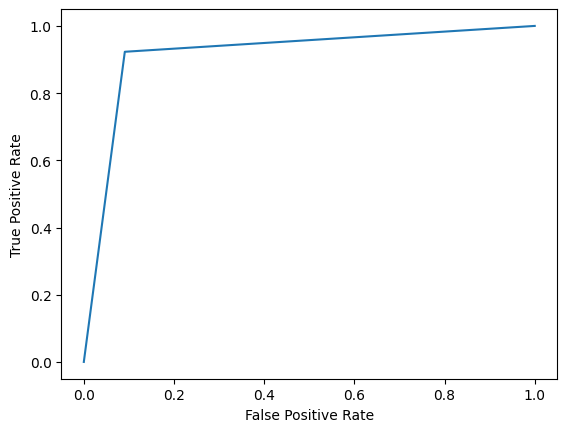

In [6]:
def metrix(prediction,clf, X_test):
    from sklearn.model_selection import cross_val_score
    accuracy_score(prediction, y_test)
    print(f"Accuracy:{accuracy_score(y_test, prediction):.3f}")
    print(f"Precision:{precision_score(y_test, prediction):.3f}")
    print(f"Recall:  {recall_score(y_test, prediction):.3f}")
    print(f"F1-score: {f1_score(y_test, prediction):.3f}")
    # print(f"ROC-AUC:{roc_auc_score(y_test, y_proba):.3f}")
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, prediction))
    print("\nClassification Report:\n", classification_report(y_test, prediction))


    scores_f1 = cross_val_score(clf, X_test, y_test, cv=5, scoring='f1')

    print(f"F1-результаты по фолдам: {scores_f1}")
    print(f"Средний F1: {scores_f1.mean():.2f}")
    from sklearn import metrics
    fpr, tpr, _ = metrics.roc_curve(y_test,  prediction)

    # построение ROC кривой
    plt.plot(fpr, tpr)
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()
    return
metrix(y_pred, model, X_test)

In [7]:
print(f"Accuracy:{accuracy_score(y_test, y_pred):.3f}")
print(f"Precision:{precision_score(y_test, y_pred):.3f}")
print(f"Recall:  {recall_score(y_test, y_pred):.3f}")
print(f"F1-score: {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC:{roc_auc_score(y_test, y_proba[:, 1]):.3f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy:0.917
Precision:0.923
Recall:  0.923
F1-score: 0.923
ROC-AUC:0.965

Confusion Matrix:
 [[10  1]
 [ 1 12]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.91      0.91      0.91        11
         1.0       0.92      0.92      0.92        13

    accuracy                           0.92        24
   macro avg       0.92      0.92      0.92        24
weighted avg       0.92      0.92      0.92        24



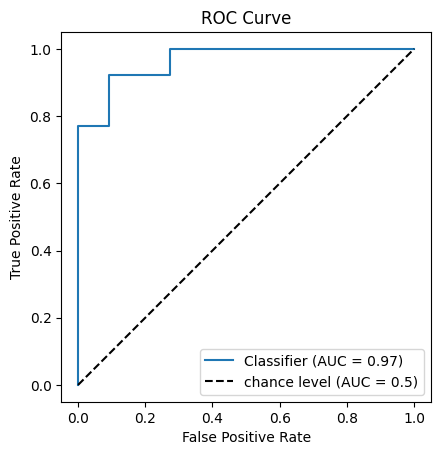

In [8]:
RocCurveDisplay.from_predictions(y_test, y_proba[:, 1])

plt.plot([0, 1], [0, 1], "k--", label="chance level (AUC = 0.5)") 
plt.axis("square")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

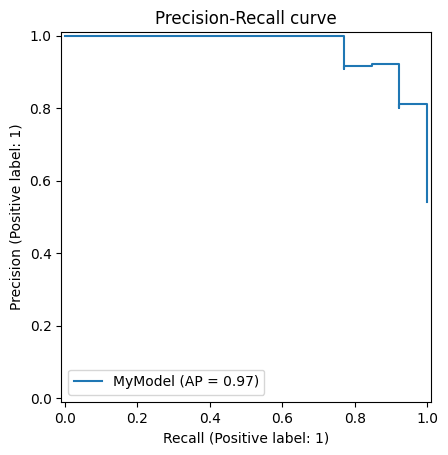

In [9]:
display = PrecisionRecallDisplay.from_predictions(y_test, y_proba[:, 1], name="MyModel")

_ = display.ax_.set_title("Precision-Recall curve")
plt.show()

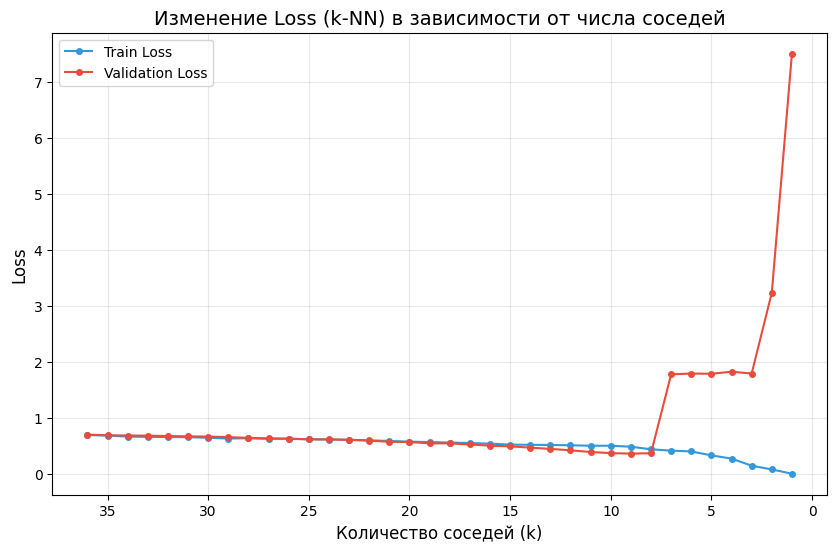

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import log_loss

# 1. Задаем диапазон k
# Определяем максимально возможное k (количество строк в X_train)
max_k = len(X_train) 

# Задаем диапазон так, чтобы он не превышал количество данных
# Обычно k не берут больше 20-30 для таких маленьких датасетов
k_values = range(1, max_k + 1) 

train_losses = []
val_losses = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    # Считаем Logloss
    train_proba = knn.predict_proba(X_train)
    val_proba = knn.predict_proba(X_test)
    
    train_losses.append(log_loss(y_train, train_proba))
    val_losses.append(log_loss(y_test, val_proba))


# 2. Визуализация
plt.figure(figsize=(10, 6))

plt.plot(k_values, train_losses, label='Train Loss', color='#3498db', marker='o', markersize=4)
plt.plot(k_values, val_losses, label='Validation Loss', color='#e74c3c', marker='o', markersize=4)


plt.title('Изменение Loss (k-NN) в зависимости от числа соседей', fontsize=14)
plt.xlabel('Количество соседей (k)', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.gca().invert_xaxis() # Инвертируем ось, так как сложность модели растет при УМЕНЬШЕНИИ k
plt.show()
